### Libraries:

In [5]:
import folium
from folium.plugins import HeatMap
import json
import requests
import networkx as nx
import matplotlib.colors as mcolors
import seaborn as sns
from math import log
import plotly.express as px
import plotly.graph_objects as go
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load your dataset
df = pd.read_csv('HappinesssGlobalData_v6.csv')

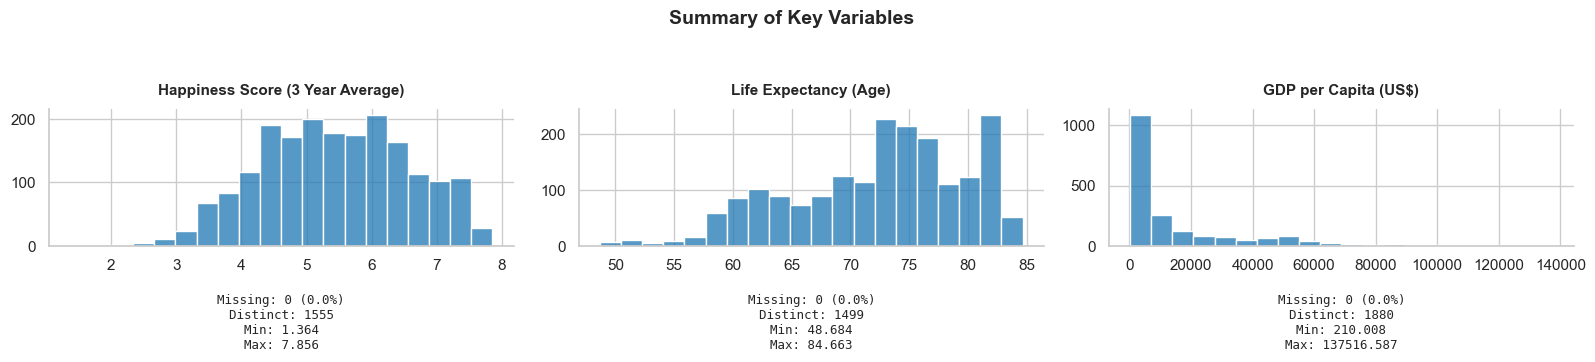

In [ ]:
cols = ['Life evaluation (3-year average)', 'Life Expectancy', 'GDP_Per_Capita']
# Custom titles for display only
titles = [
    'Happiness Score (3 Year Average)',
    'Life Expectancy (Age)',
    'GDP per Capita (US$)'
]
plt.figure(figsize=(16, 4))
sns.set_theme(style='whitegrid')

for i, (col, title) in enumerate(zip(cols, titles), 1):
    plt.subplot(1, len(cols), i)
    sns.histplot(df[col], bins=20, color='#1f77b4', kde=False)
    plt.title(title, fontsize=11, weight='bold', pad=10)
    plt.xlabel('')
    plt.ylabel('')
    
    # Compute stats
    missing = df[col].isna().sum()
    missing_pct = (missing / len(df)) * 100
    distinct = df[col].nunique()
    min_val = df[col].min()
    max_val = df[col].max()
    
    # Add summary text below each plot
    text = (f"Missing: {missing} ({missing_pct:.1f}%)\n"
            f"Distinct: {distinct}\n"
            f"Min: {min_val:.3f}\n"
            f"Max: {max_val:.3f}")
    
    plt.text(
        0.5, -0.35, text,
        transform=plt.gca().transAxes,
        fontsize=9,
        ha='center', va='top',
        family='monospace'
    )

plt.suptitle('Summary of Key Variables', fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
sns.despine()
plt.show()


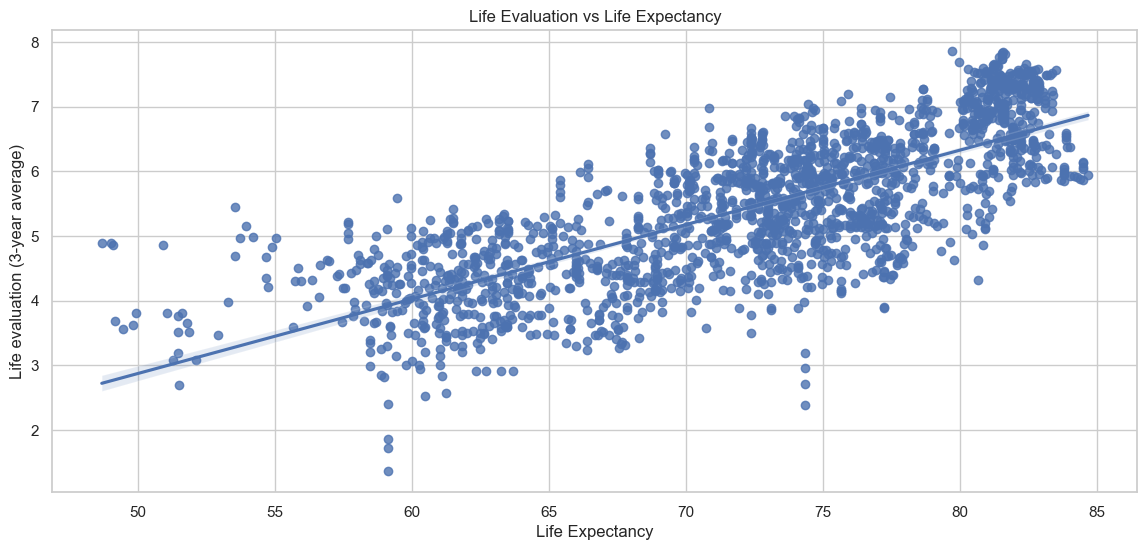

In [9]:
plt.figure(figsize=(14, 6))
# Scatter plot for Life evaluation vs Life Expectancy
sns.regplot(x='Life Expectancy', y='Life evaluation (3-year average)', data=df)
plt.title('Life Evaluation vs Life Expectancy')
plt.xlabel('Life Expectancy')
plt.ylabel('Life evaluation (3-year average)')
plt.show()

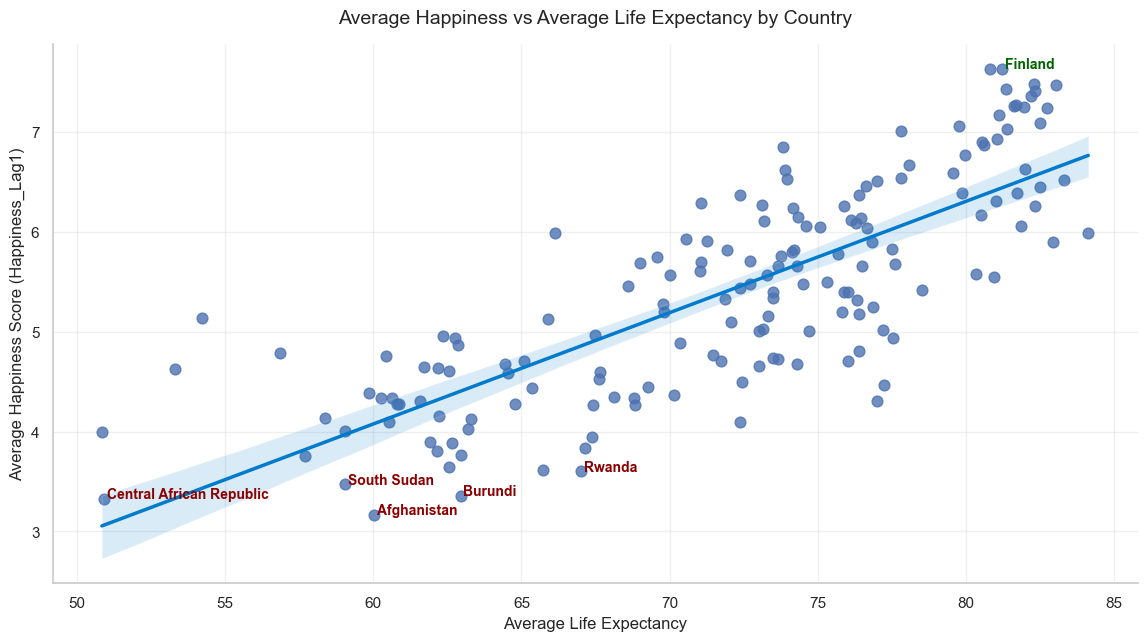

In [ ]:
country_avg = df.groupby('Country')[['Happiness_Lag1', 'Life Expectancy']].mean().reset_index()
# Create the scatter plot
plt.figure(figsize=(14, 7))
sns.regplot(
    x='Life Expectancy',
    y='Happiness_Lag1',
    data=country_avg,
    scatter_kws={'s': 60, 'alpha': 0.8},
    line_kws={'color': '#007acc', 'lw': 2.5}
)
# Identify the top 2 and bottom 2 countries based on Happiness_Lag1
top2 = country_avg.nlargest(1, 'Happiness_Lag1')
bottom2 = country_avg.nsmallest(5, 'Happiness_Lag1')
# Annotate them clearly and aesthetically
for _, row in pd.concat([top2, bottom2]).iterrows():
    plt.text(
        row['Life Expectancy'] + 0.1,  # slight offset for visibility
        row['Happiness_Lag1'],
        row['Country'],
        fontsize=10,
        color='darkred' if row['Happiness_Lag1'] in bottom2['Happiness_Lag1'].values else 'darkgreen',
        fontweight='bold'
    )
plt.title('Average Happiness vs Average Life Expectancy by Country', fontsize=14, pad=15)
plt.xlabel('Average Life Expectancy', fontsize=12)
plt.ylabel('Average Happiness Score (Happiness_Lag1)', fontsize=12)
plt.grid(alpha=0.3)
sns.despine()

plt.show()

In [ ]:
# Calculate average happiness by country
country_happiness = df.groupby('Country')['Happiness_Lag1'].mean().reset_index()
country_happiness.columns = ['Country', 'Avg_Happiness']

# Define continent mapping (simplified - you might want to use a proper mapping)
continent_mapping = {
    'Asia': ['Afghanistan', 'Armenia', 'Azerbaijan', 'Bahrain', 'Bangladesh', 'Bhutan', 'Cambodia', 'China', 'Cyprus', 'India', 'Indonesia', 'Japan', 'Kazakhstan', 'Kuwait', 'Kyrgyzstan', 'Laos', 'Lebanon', 'Malaysia', 'Maldives', 'Mongolia', 'Myanmar', 'Nepal', 'Oman', 'Pakistan', 'Philippines', 'Qatar', 'Saudi Arabia', 'Singapore', 'South Korea', 'Sri Lanka', 'Taiwan', 'Tajikistan', 'Thailand', 'Turkey', 'Turkmenistan', 'United Arab Emirates', 'Uzbekistan', 'Vietnam', 'Yemen'],
    'Europe': ['Albania', 'Andorra', 'Austria', 'Belarus', 'Belgium', 'Bosnia and Herzegovina', 'Bulgaria', 'Croatia', 'Czechia', 'Denmark', 'Estonia', 'Finland', 'France', 'Germany', 'Greece', 'Hungary', 'Iceland', 'Ireland', 'Italy', 'Kosovo', 'Latvia', 'Liechtenstein', 'Lithuania', 'Luxembourg', 'Malta', 'Moldova', 'Monaco', 'Montenegro', 'Netherlands', 'North Macedonia', 'Norway', 'Poland', 'Portugal', 'Romania', 'Russia', 'San Marino', 'Serbia', 'Slovakia', 'Slovenia', 'Spain', 'Sweden', 'Switzerland', 'Ukraine', 'United Kingdom', 'Vatican City'],
    'Africa': ['Algeria', 'Angola', 'Benin', 'Botswana', 'Burkina Faso', 'Burundi', 'Cabo Verde', 'Cameroon', 'Central African Republic', 'Chad', 'Comoros', 'Congo', 'DR Congo', 'Djibouti', 'Egypt', 'Equatorial Guinea', 'Eritrea', 'Eswatini', 'Ethiopia', 'Gabon', 'Gambia', 'Ghana', 'Guinea', 'Guinea-Bissau', 'Ivory Coast', 'Kenya', 'Lesotho', 'Liberia', 'Libya', 'Madagascar', 'Malawi', 'Mali', 'Mauritania', 'Mauritius', 'Morocco', 'Mozambique', 'Namibia', 'Niger', 'Nigeria', 'Rwanda', 'Sao Tome and Principe', 'Senegal', 'Seychelles', 'Sierra Leone', 'Somalia', 'South Africa', 'South Sudan', 'Sudan', 'Tanzania', 'Togo', 'Tunisia', 'Uganda', 'Zambia', 'Zimbabwe'],
    'North America': ['Antigua and Barbuda', 'Bahamas', 'Barbados', 'Belize', 'Canada', 'Costa Rica', 'Cuba', 'Dominica', 'Dominican Republic', 'El Salvador', 'Grenada', 'Guatemala', 'Haiti', 'Honduras', 'Jamaica', 'Mexico', 'Nicaragua', 'Panama', 'Saint Kitts and Nevis', 'Saint Lucia', 'Saint Vincent and the Grenadines', 'Trinidad and Tobago', 'United States'],
    'South America': ['Argentina', 'Bolivia', 'Brazil', 'Chile', 'Colombia', 'Ecuador', 'Guyana', 'Paraguay', 'Peru', 'Suriname', 'Uruguay', 'Venezuela'],
    'Australia': ['Australia', 'Fiji', 'Kiribati', 'Marshall Islands', 'Micronesia', 'Nauru', 'New Zealand', 'Palau', 'Papua New Guinea', 'Samoa', 'Solomon Islands', 'Tonga', 'Tuvalu', 'Vanuatu']
}

# Add continents to our data
def get_continent(country):
    for continent, countries in continent_mapping.items():
        if country in countries:
            return continent
    return 'MiddleEast'  

country_happiness['Continent'] = country_happiness['Country'].apply(get_continent)

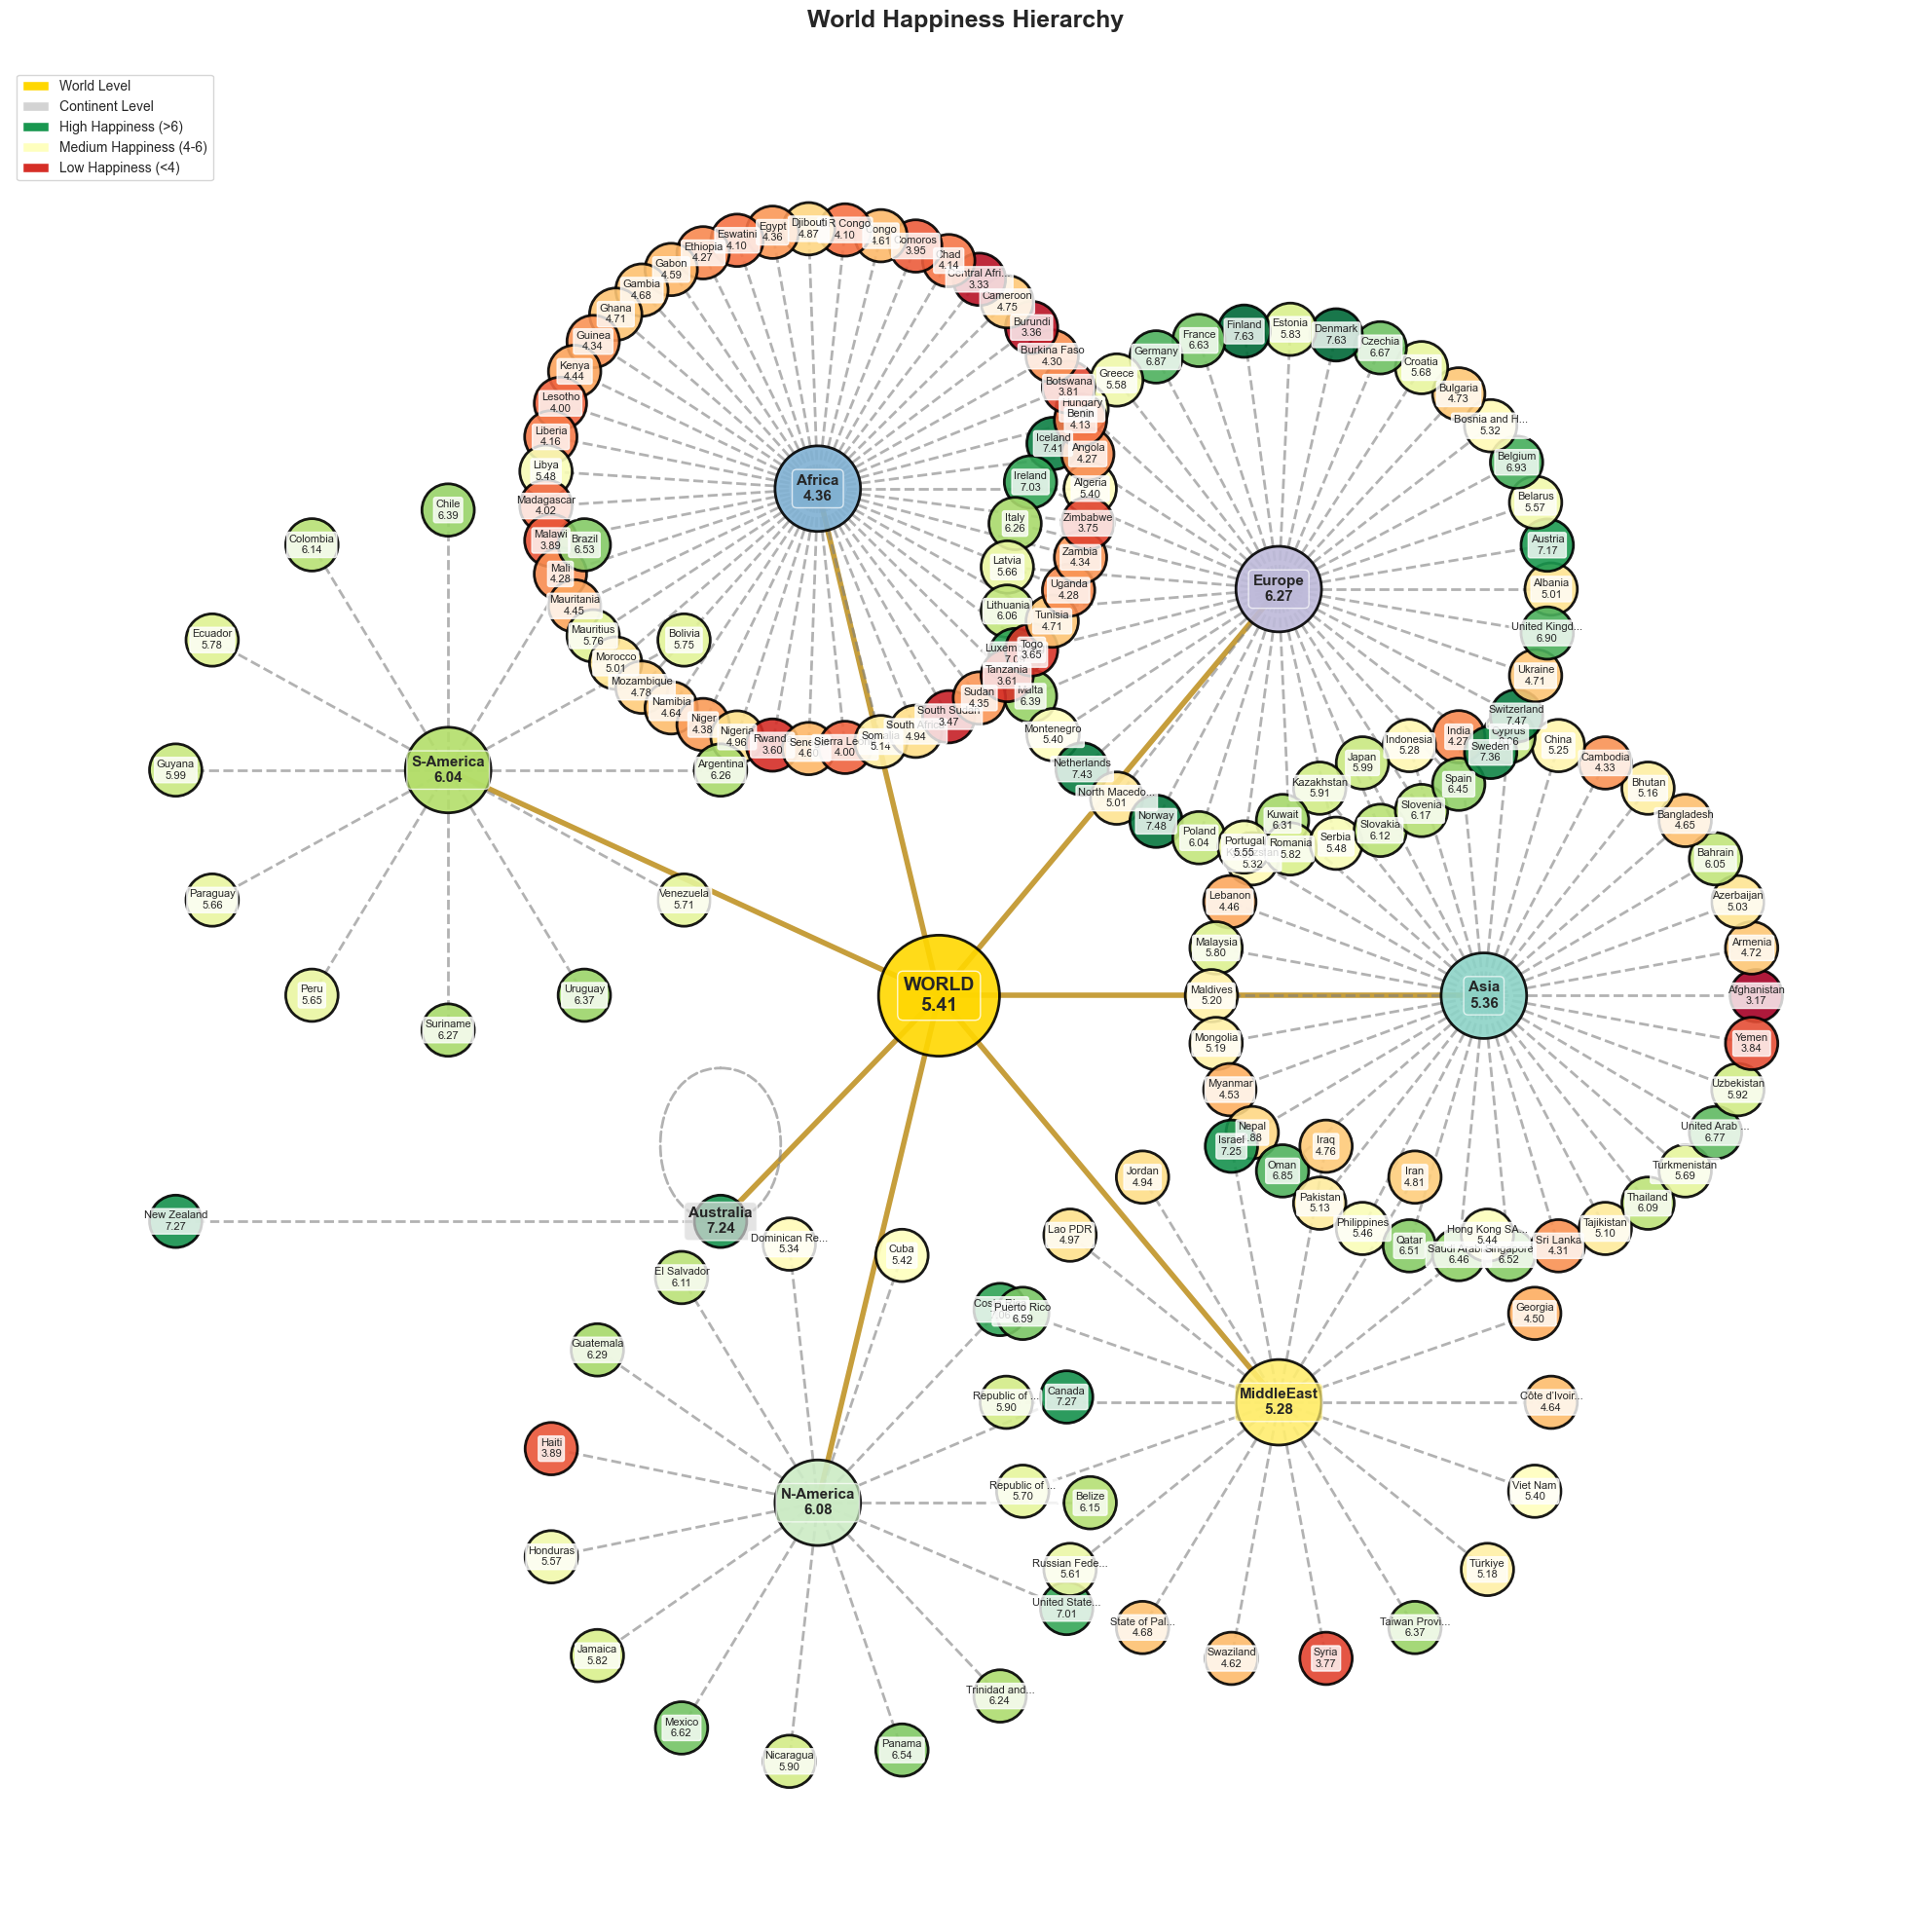

In [ ]:
plt.figure(figsize=(20, 20))
# Create graph
G_radial = nx.Graph()

# Calculate positions manually for proper radial layout
def create_radial_positions(G, center_node, second_layer_nodes, third_layer_nodes):
    pos = {}
    
    # Center node
    pos[center_node] = (0, 0)
    
    # Second layer (continents) - placed in a circle
    num_continents = len(second_layer_nodes)
    continent_radius = 3
    for i, continent in enumerate(second_layer_nodes):
        angle = 2 * np.pi * i / num_continents
        x = continent_radius * np.cos(angle)
        y = continent_radius * np.sin(angle)
        pos[continent] = (x, y)
    
    # Third layer (countries) - placed in circles around their continents
    country_radius = 1.5
    for continent in second_layer_nodes:
        continent_countries = [node for node in third_layer_nodes if G.has_edge(continent, node)]
        num_countries = len(continent_countries)
        
        if num_countries > 0:
            continent_pos = pos[continent]
            for j, country in enumerate(continent_countries):
                angle = 2 * np.pi * j / num_countries
                x = continent_pos[0] + country_radius * np.cos(angle)
                y = continent_pos[1] + country_radius * np.sin(angle)
                pos[country] = (x, y)
    
    return pos

# Add nodes and edges with proper hierarchy
continents = country_happiness['Continent'].unique()
countries = country_happiness['Country'].values

# Center node
G_radial.add_node('World', size=8000, color='gold', happiness=country_happiness['Avg_Happiness'].mean())

# Second layer: Continents
continent_colors = plt.cm.Set3(np.linspace(0, 1, len(continents)))
continent_color_map = {continent: color for continent, color in zip(continents, continent_colors)}

for i, continent in enumerate(continents):
    continent_data = country_happiness[country_happiness['Continent'] == continent]
    continent_avg = continent_data['Avg_Happiness'].mean()
    G_radial.add_node(continent, size=4000, color=continent_color_map[continent], happiness=continent_avg)
    G_radial.add_edge('World', continent)
    
    # Third layer: Countries
    for _, country_row in continent_data.iterrows():
        country = country_row['Country']
        happiness = country_row['Avg_Happiness']
        
        # Color countries based on happiness score
        norm_happiness = (happiness - country_happiness['Avg_Happiness'].min()) / (country_happiness['Avg_Happiness'].max() - country_happiness['Avg_Happiness'].min())
        country_color = plt.cm.RdYlGn(norm_happiness)
        
        G_radial.add_node(country, size=1500, color=country_color, happiness=happiness)
        G_radial.add_edge(continent, country)

# Create manual radial layout
pos = create_radial_positions(G_radial, 'World', continents, countries)

# Draw nodes with colors and sizes
node_colors = [G_radial.nodes[node]['color'] for node in G_radial.nodes()]
node_sizes = [G_radial.nodes[node]['size'] for node in G_radial.nodes()]

# Draw with better styling
nx.draw_networkx_nodes(G_radial, pos, 
                      node_color=node_colors, 
                      node_size=node_sizes, 
                      alpha=0.9,
                      edgecolors='black',
                      linewidths=2)

# Draw edges with different styles for each layer
world_edges = [(u, v) for u, v in G_radial.edges() if u == 'World' or v == 'World']
continent_edges = [(u, v) for u, v in G_radial.edges() if u not in ['World'] and v not in ['World'] and (u in continents or v in continents)]

nx.draw_networkx_edges(G_radial, pos, 
                      edgelist=world_edges,
                      edge_color='darkgoldenrod',
                      width=4,
                      alpha=0.8,
                      style='-')

nx.draw_networkx_edges(G_radial, pos, 
                      edgelist=continent_edges,
                      edge_color='gray',
                      width=2,
                      alpha=0.6,
                      style='--')

# Add labels with better formatting
labels = {}
for node in G_radial.nodes():
    happiness = G_radial.nodes[node]['happiness']
    if node == 'World':
        labels[node] = f'WORLD\n{happiness:.2f}'
    elif node in continents:
        # Shorten continent names for better display
        short_name = node.split()[0] if ' ' in node else node[:10]
        labels[node] = f'{short_name}\n{happiness:.2f}'
    else:
        # Shorten country names and show happiness
        short_name = node[:12] + '...' if len(node) > 12 else node
        labels[node] = f'{short_name}\n{happiness:.2f}'

# Draw labels with different font sizes
label_pos = {k: (v[0], v[1]) for k, v in pos.items()}
for node, (x, y) in pos.items():
    if node == 'World':
        plt.text(x, y, labels[node], 
                fontsize=14, fontweight='bold', 
                ha='center', va='center',
                bbox=dict(boxstyle="round,pad=0.3", facecolor='gold', alpha=0.8))
    elif node in continents:
        plt.text(x, y, labels[node], 
                fontsize=11, fontweight='bold',
                ha='center', va='center',
                bbox=dict(boxstyle="round,pad=0.3", facecolor=continent_color_map[node], alpha=0.7))
    else:
        plt.text(x, y, labels[node], 
                fontsize=8, fontweight='normal',
                ha='center', va='center',
                bbox=dict(boxstyle="round,pad=0.2", facecolor='white', alpha=0.8))

# Add legend for happiness colors
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='gold', label='World Level'),
    Patch(facecolor='lightgray', label='Continent Level'),
    Patch(facecolor=plt.cm.RdYlGn(0.9), label='High Happiness (>6)'),
    Patch(facecolor=plt.cm.RdYlGn(0.5), label='Medium Happiness (4-6)'),
    Patch(facecolor=plt.cm.RdYlGn(0.1), label='Low Happiness (<4)')
]

plt.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(0, 1), fontsize=10)

plt.title('World Happiness Hierarchy', 
          size=18, pad=30, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()


In [ ]:
# Prepare data for sunburst
sunburst_data = []
for _, row in country_happiness.iterrows():
    sunburst_data.append({
        'id': row['Country'],
        'parent': row['Continent'],
        'value': row['Avg_Happiness'],
        'label': f"{row['Country']}: {row['Avg_Happiness']:.2f}"
    })

# Add continent nodes
for continent in continents:
    continent_avg = country_happiness[country_happiness['Continent'] == continent]['Avg_Happiness'].mean()
    sunburst_data.append({
        'id': continent,
        'parent': 'World',
        'value': continent_avg,
        'label': f"{continent}: {continent_avg:.2f}"
    })

# Add world node
sunburst_data.append({
    'id': 'World',
    'parent': '',
    'value': country_happiness['Avg_Happiness'].mean(),
    'label': f"World: {country_happiness['Avg_Happiness'].mean():.2f}"
})

# Create sunburst
fig_sunburst = px.sunburst(
    sunburst_data,
    names='id',
    parents='parent',
    values='value',
    title='World Happiness Distribution by Continent and Country',
    color='value',
    color_continuous_scale='Viridis',
    hover_data={'label': True}
)

fig_sunburst.update_layout(
    width=800,
    height=800,
    font=dict(size=12)
)

fig_sunburst.show()

In [ ]:
# Calculate average happiness by country
happiness_avg = df.groupby('Country')['Happiness_Lag1'].mean().reset_index()

# Get world coordinates data
world_geo = 'https://raw.githubusercontent.com/python-visualization/folium/master/examples/data/world-countries.json'

# Create base map
m1 = folium.Map(location=[20, 0], zoom_start=2)

# Create choropleth
folium.Choropleth(
    geo_data=world_geo,
    name='choropleth',
    data=happiness_avg,
    columns=['Country', 'Happiness_Lag1'],
    key_on='feature.properties.name',
    fill_color='YlOrRd',
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name='Average Happiness Score (Happiness_Lag1)',
    bins=8,
    reset=True
).add_to(m1)

folium.LayerControl().add_to(m1)
m1.save('pictures/happiness_choropleth_basic.html')
m1

In [ ]:
# Define continent mapping
continent_mapping = {
    'Asia': ['Afghanistan', 'Armenia', 'Azerbaijan', 'Bahrain', 'Bangladesh', 'Bhutan', 'Cambodia', 'China', 'Cyprus', 'India', 'Indonesia', 'Japan', 'Kazakhstan', 'Kuwait', 'Kyrgyzstan', 'Laos', 'Lebanon', 'Malaysia', 'Maldives', 'Mongolia', 'Myanmar', 'Nepal', 'Oman', 'Pakistan', 'Philippines', 'Qatar', 'Saudi Arabia', 'Singapore', 'South Korea', 'Sri Lanka', 'Taiwan', 'Tajikistan', 'Thailand', 'Turkey', 'Turkmenistan', 'United Arab Emirates', 'Uzbekistan', 'Vietnam', 'Yemen'],
    'Europe': ['Albania', 'Andorra', 'Austria', 'Belarus', 'Belgium', 'Bosnia and Herzegovina', 'Bulgaria', 'Croatia', 'Czechia', 'Denmark', 'Estonia', 'Finland', 'France', 'Germany', 'Greece', 'Hungary', 'Iceland', 'Ireland', 'Italy', 'Kosovo', 'Latvia', 'Liechtenstein', 'Lithuania', 'Luxembourg', 'Malta', 'Moldova', 'Monaco', 'Montenegro', 'Netherlands', 'North Macedonia', 'Norway', 'Poland', 'Portugal', 'Romania', 'Russia', 'San Marino', 'Serbia', 'Slovakia', 'Slovenia', 'Spain', 'Sweden', 'Switzerland', 'Ukraine', 'United Kingdom', 'Vatican City'],
    'Africa': ['Algeria', 'Angola', 'Benin', 'Botswana', 'Burkina Faso', 'Burundi', 'Cabo Verde', 'Cameroon', 'Central African Republic', 'Chad', 'Comoros', 'Congo', 'DR Congo', 'Djibouti', 'Egypt', 'Equatorial Guinea', 'Eritrea', 'Eswatini', 'Ethiopia', 'Gabon', 'Gambia', 'Ghana', 'Guinea', 'Guinea-Bissau', 'Ivory Coast', 'Kenya', 'Lesotho', 'Liberia', 'Libya', 'Madagascar', 'Malawi', 'Mali', 'Mauritania', 'Mauritius', 'Morocco', 'Mozambique', 'Namibia', 'Niger', 'Nigeria', 'Rwanda', 'Sao Tome and Principe', 'Senegal', 'Seychelles', 'Sierra Leone', 'Somalia', 'South Africa', 'South Sudan', 'Sudan', 'Tanzania', 'Togo', 'Tunisia', 'Uganda', 'Zambia', 'Zimbabwe'],
    'North America': ['Antigua and Barbuda', 'Bahamas', 'Barbados', 'Belize', 'Canada', 'Costa Rica', 'Cuba', 'Dominica', 'Dominican Republic', 'El Salvador', 'Grenada', 'Guatemala', 'Haiti', 'Honduras', 'Jamaica', 'Mexico', 'Nicaragua', 'Panama', 'Saint Kitts and Nevis', 'Saint Lucia', 'Saint Vincent and the Grenadines', 'Trinidad and Tobago', 'United States'],
    'South America': ['Argentina', 'Bolivia', 'Brazil', 'Chile', 'Colombia', 'Ecuador', 'Guyana', 'Paraguay', 'Peru', 'Suriname', 'Uruguay', 'Venezuela'],
    'Australia': ['Australia', 'Fiji', 'Kiribati', 'Marshall Islands', 'Micronesia', 'Nauru', 'New Zealand', 'Palau', 'Papua New Guinea', 'Samoa', 'Solomon Islands', 'Tonga', 'Tuvalu', 'Vanuatu']
}

# Function to get continent
def get_continent(country):
    for continent, countries in continent_mapping.items():
        if country in countries:
            return continent
    return 'MiddleEast'

# First, calculate averages by country
country_analysis = df.groupby('Country').agg({
    'Life Expectancy': 'mean',
    'Life evaluation (3-year average)': 'mean',
    'GDP_Per_Capita': 'mean'
}).reset_index()

country_analysis.columns = ['Country', 'Avg_Life_Expectancy', 'Avg_Happiness', 'Avg_GDP_Per_Capita']
country_analysis['Continent'] = country_analysis['Country'].apply(get_continent)

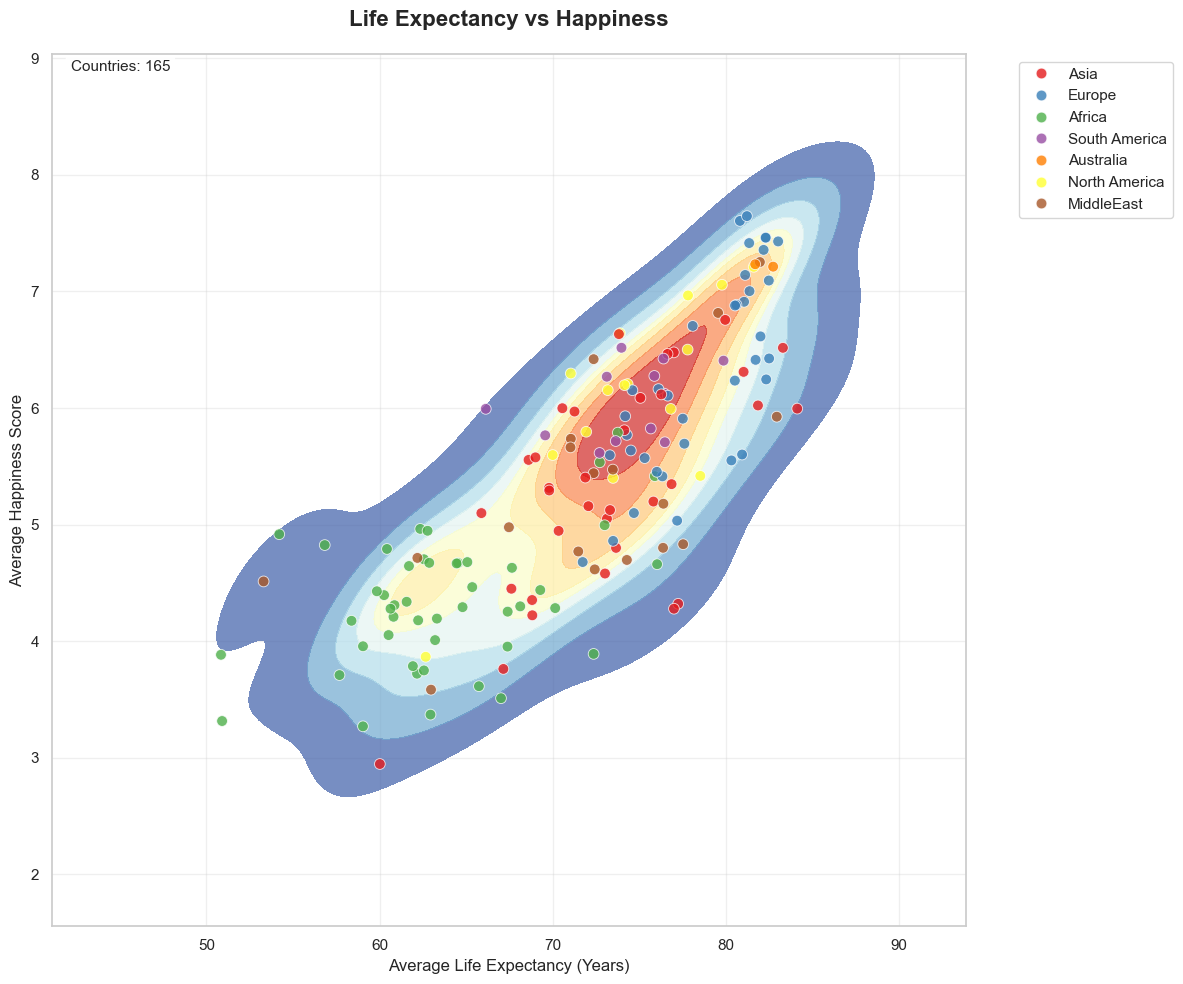

In [ ]:
plt.figure(figsize=(12, 10))

# Create density contour plot
sns.kdeplot(data=country_analysis, 
            x='Avg_Life_Expectancy', 
            y='Avg_Happiness',
            fill=True,
            cmap='RdYlBu_r',
            alpha=0.7,
            levels=10)

# Add scatter points
sns.scatterplot(data=country_analysis, 
                x='Avg_Life_Expectancy', 
                y='Avg_Happiness',
                hue='Continent',
                palette='Set1',
                s=60,
                alpha=0.8)
# Density Contour + Scatter plot
plt.title('Life Expectancy vs Happiness', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Average Life Expectancy (Years)', fontsize=12)
plt.ylabel('Average Happiness Score', fontsize=12)
plt.grid(alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.text(0.02, 0.98, f'Countries: {len(country_analysis)}', 
         transform=plt.gca().transAxes, fontsize=11,
         bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.9))

plt.tight_layout()
plt.show()

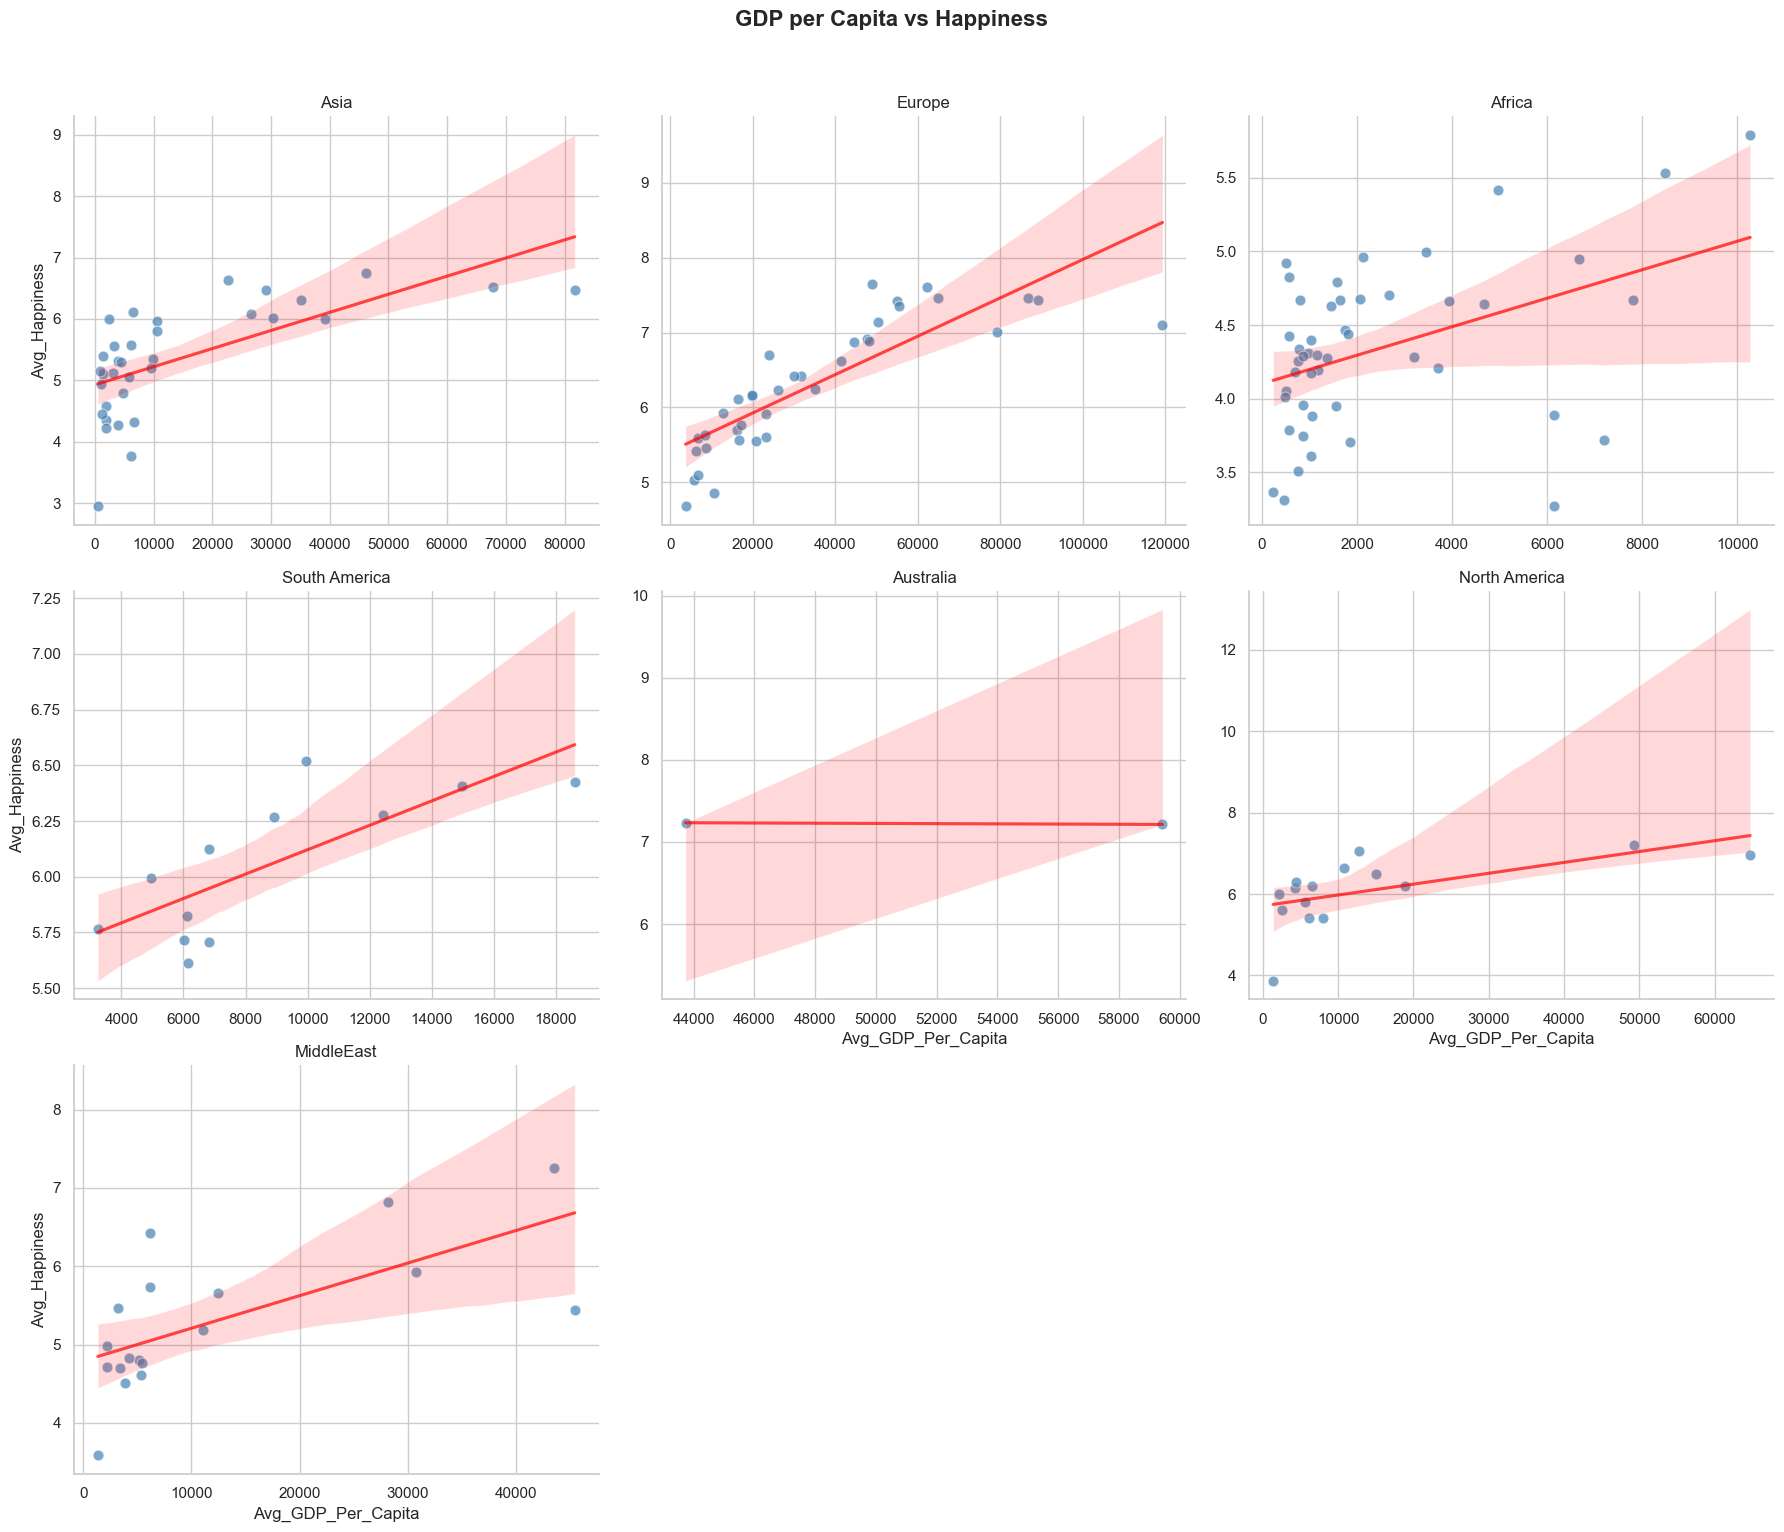

In [20]:
# Create facet grid
g = sns.FacetGrid(country_analysis, col='Continent', col_wrap=3, 
                  height=5, aspect=1.2, sharex=False, sharey=False)
g.map_dataframe(sns.scatterplot, x='Avg_GDP_Per_Capita', y='Avg_Happiness', 
                alpha=0.7, s=60, color='steelblue')
g.set_titles('{col_name}')
g.set_axis_labels('GDP per Capita (USD)', 'Happiness Score')

# Add regression lines
g.map_dataframe(sns.regplot, x='Avg_GDP_Per_Capita', y='Avg_Happiness', 
                scatter=False, color='red', line_kws={'alpha': 0.7})

plt.suptitle('GDP per Capita vs Happiness', 
             fontsize=16, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

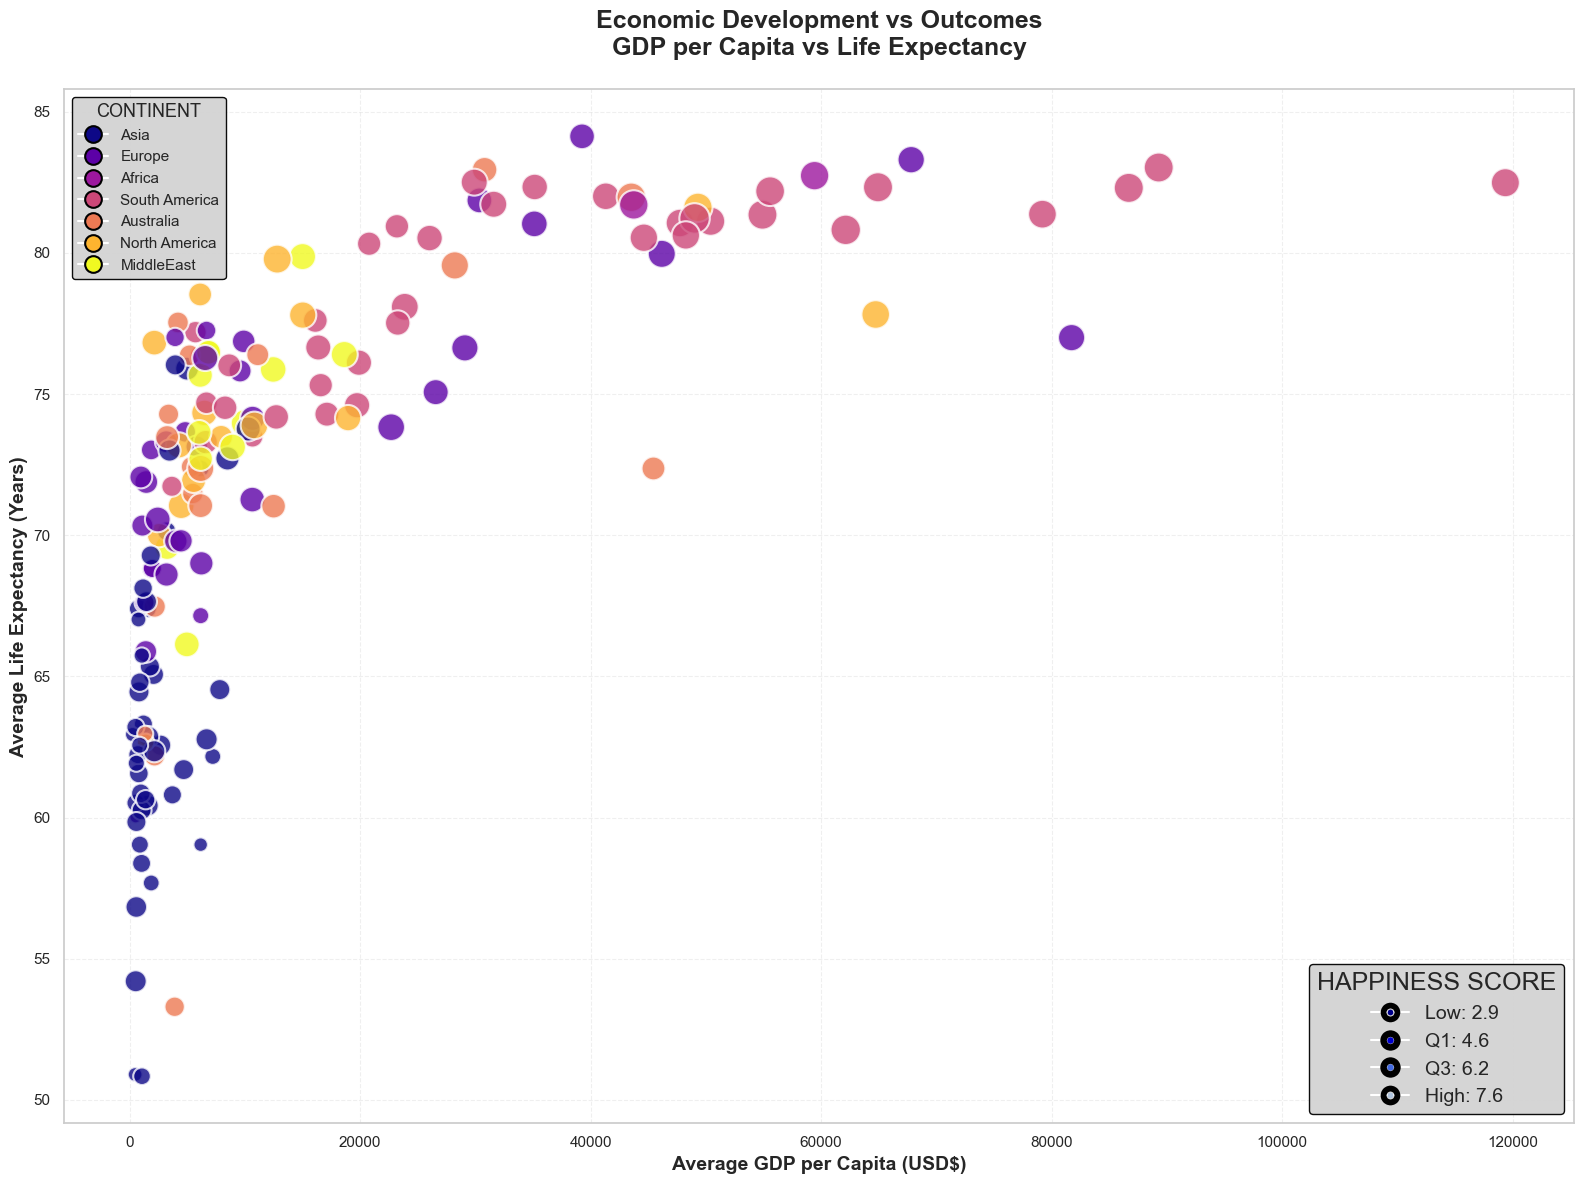

In [ ]:
plt.figure(figsize=(16, 12))

# Calculate point sizes based on happiness score (normalized)
happiness_norm = (country_analysis['Avg_Happiness'] - country_analysis['Avg_Happiness'].min()) / \
                (country_analysis['Avg_Happiness'].max() - country_analysis['Avg_Happiness'].min())
point_sizes = 80 + happiness_norm * 400  # Larger point sizes for better visibility

# Create scatter plot with plasma colormap
scatter = plt.scatter(country_analysis['Avg_GDP_Per_Capita'], 
                     country_analysis['Avg_Life_Expectancy'],
                     c=pd.Categorical(country_analysis['Continent']).codes,
                     cmap='plasma',  # Using plasma colormap
                     s=point_sizes,
                     alpha=0.8,
                     edgecolors='white',
                     linewidth=1.5)

plt.title('Economic Development vs Outcomes\nGDP per Capita vs Life Expectancy', 
          fontsize=18, fontweight='bold', pad=25)
plt.xlabel('Average GDP per Capita (USD$)', fontsize=14, fontweight='bold')
plt.ylabel('Average Life Expectancy (Years)', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3, linestyle='--', linewidth=0.8)

# Create custom legend for continents with better styling
continents = country_analysis['Continent'].unique()
colors = plt.cm.plasma(np.linspace(0, 1, len(continents)))
continent_legend_elements = [plt.Line2D([0], [0], marker='o', color='w', 
                            markerfacecolor=colors[i], markersize=12, 
                            markeredgecolor='black', markeredgewidth=1.5,
                            label=continent) 
                 for i, continent in enumerate(continents)]

# Create size legend for happiness scores with better scaling
happiness_min = country_analysis['Avg_Happiness'].min()
happiness_max = country_analysis['Avg_Happiness'].max()
happiness_q1 = country_analysis['Avg_Happiness'].quantile(0.25)
happiness_q3 = country_analysis['Avg_Happiness'].quantile(0.75)

def get_legend_size(happiness_val):
    norm_val = (happiness_val - happiness_min) / (happiness_max - happiness_min)
    actual_size = 80 + norm_val * 400
    return np.sqrt(actual_size) / 8  # Scale for legend display

size_legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', 
               markerfacecolor='darkblue', 
               markersize=get_legend_size(happiness_min*5), 
               markeredgecolor='black', markeredgewidth=10,
               label=f'Low: {happiness_min:.1f}'),
    plt.Line2D([0], [0], marker='o', color='w', 
               markerfacecolor='mediumblue', 
               markersize=get_legend_size(happiness_q1*4), 
               markeredgecolor='black', markeredgewidth=10,
               label=f'Q1: {happiness_q1:.1f}'),
    plt.Line2D([0], [0], marker='o', color='w', 
               markerfacecolor='royalblue', 
               markersize=get_legend_size(happiness_q3*3), 
               markeredgecolor='black', markeredgewidth=10,
               label=f'Q3: {happiness_q3:.1f}'),
    plt.Line2D([0], [0], marker='o', color='w', 
               markerfacecolor='lightsteelblue', 
               markersize=get_legend_size(happiness_max*2), 
               markeredgecolor='black', markeredgewidth=10,
               label=f'High: {happiness_max:.1f}')
]
legend1 = plt.legend(handles=continent_legend_elements, 
                   loc='upper left', 
                   title='CONTINENT',
                   title_fontsize=13,
                   fontsize=11,
                   frameon=True,
                   framealpha=0.95,
                   edgecolor='black',
                   facecolor='lightgray')
plt.gca().add_artist(legend1)
legend2 = plt.legend(handles=size_legend_elements, 
                   loc='lower right', 
                   title='HAPPINESS SCORE',
                   title_fontsize=18,
                   fontsize=14,
                   frameon=True,
                   framealpha=0.95,
                   edgecolor='black',
                   facecolor='lightgray')
plt.tight_layout()
plt.show()


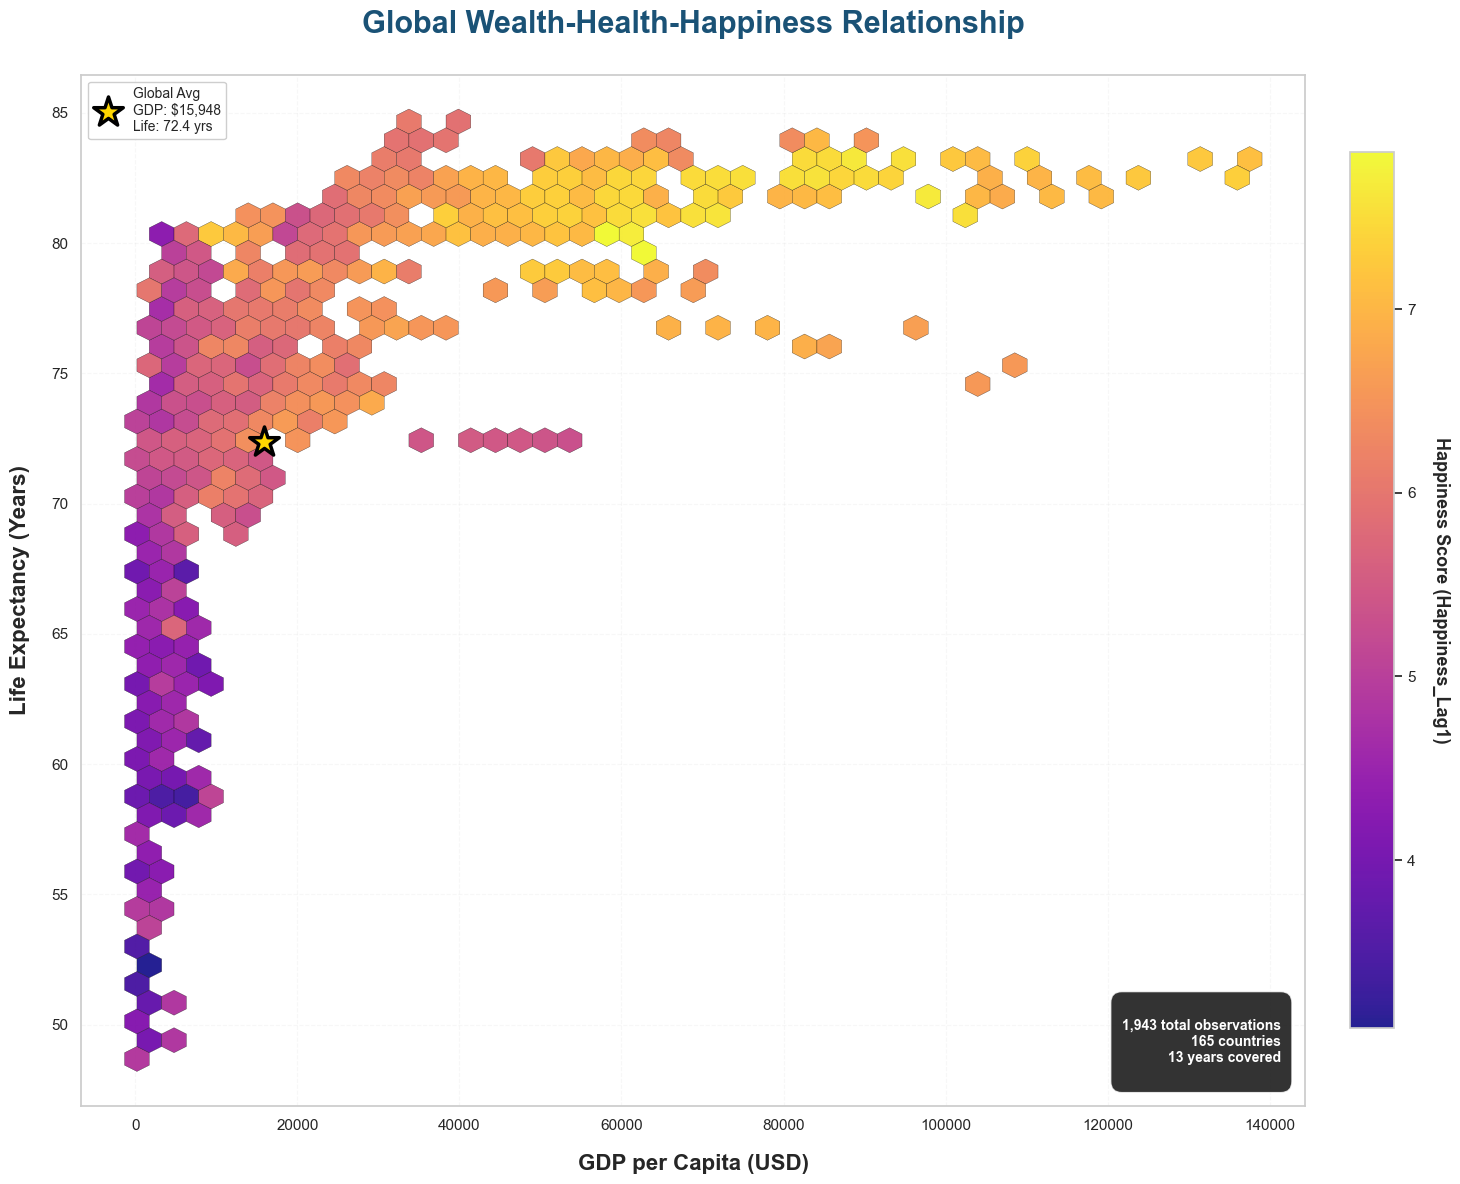

In [ ]:
# Calculate global averages for the three variables
global_gdp = df['GDP_Per_Capita'].mean()
global_life_exp = df['Life Expectancy'].mean()
global_happiness = df['Happiness_Lag1'].mean()
plt.figure(figsize=(16, 12))

# Create hexbin with plasma colormap
hexbin = plt.hexbin(df['GDP_Per_Capita'], 
                   df['Life Expectancy'],
                   C=df['Happiness_Lag1'],
                   gridsize=45,
                   cmap='plasma',
                   alpha=0.9,
                   edgecolors='black',
                   linewidth=0.2,
                   reduce_C_function=np.mean,
                   mincnt=1)

plt.title('Global Wealth-Health-Happiness Relationship', 
          fontsize=22, fontweight='bold', pad=30, color='#1a5276')
plt.xlabel('GDP per Capita (USD)', fontsize=16, fontweight='bold', labelpad=15)
plt.ylabel('Life Expectancy (Years)', fontsize=16, fontweight='bold', labelpad=15)

# Enhanced colorbar
cbar = plt.colorbar(hexbin, shrink=0.85, pad=0.03)
cbar.set_label('Happiness Score (Happiness_Lag1)', 
               rotation=270, labelpad=25, fontweight='bold', fontsize=13)

# Add global average
plt.scatter(global_gdp, global_life_exp, 
           s=500, color='gold', marker='*', 
           edgecolors='black', linewidth=2.5, 
           alpha=1.0, zorder=5,
           label=f'Global Avg\nGDP: ${global_gdp:,.0f}\nLife: {global_life_exp:.1f} yrs')

plt.grid(True, alpha=0.15, linestyle='--', linewidth=0.8)

# Simplified stats
simple_stats = f'''
{len(df):,} total observations
{df["Country"].nunique()} countries
{df["Year"].nunique()} years covered
'''

plt.text(0.98, 0.10, simple_stats, transform=plt.gca().transAxes, fontsize=10,
        bbox=dict(boxstyle="round,pad=0.8", facecolor='black', alpha=0.8, 
                 edgecolor='white'),
        color='white', fontweight='bold', ha='right', verticalalignment='top')

plt.legend(loc='upper left', framealpha=0.95, fontsize=10)

plt.tight_layout()
plt.show()